# Preconditioning Experiments

In [12]:
import importlib
import inspect
import numpy as np
import preconditioner as pre
import preconditioner.workbench as wb_mod

importlib.reload(wb_mod)
importlib.reload(pre)

from preconditioner import (
    apply_plot_style,
    PreconditionerWorkbench,
    plot_delta_kappa_vs_n,
    plot_delta_kappa_vs_kappa,
    plot_iterations_vs_n,
    plot_time_vs_n,
    plot_time_vs_kappa,
    build_inverse_dataset,
    RidgeInverseApproximator,
    evaluate_inverse_model,
)

apply_plot_style()
lab = PreconditionerWorkbench()
print('run_size_sweep signature:', inspect.signature(lab.run_size_sweep))


run_size_sweep signature: (*, sizes: 'Optional[Iterable[int]]' = None, n_samples: 'int' = 6, family_count: 'Optional[int]' = None, preconditioner_names: 'Optional[Sequence[str]]' = None, solver_names: 'Optional[Sequence[str]]' = None, rng_seed: 'int' = 7, tol: 'float' = 1e-08, maxiter: 'int' = 400, signed_kappa: 'bool' = True, kappa_bins: 'int' = 12) -> 'SweepResult'


## Конфигурация

In [ ]:
# Быстрый режим работы
fast_mode = True

if fast_mode:
    sizes = lab.default_sizes(min_size=16, max_size=128, count=5)
    n_samples = 2
    family_count = 3
    preconditioner_names = ('None', 'Diagonal', 'LU')
    solver_names = ('GMRES',)
    maxiter = 120
else:
    sizes = lab.default_sizes(min_size=16, max_size=512, count=8)
    n_samples = 4
    family_count = None
    preconditioner_names = None
    solver_names = None
    maxiter = 400

kwargs = dict(
    sizes=sizes,
    n_samples=n_samples,
    family_count=family_count,
    preconditioner_names=preconditioner_names,
    solver_names=solver_names,
    rng_seed=7,
    tol=1e-8,
    maxiter=maxiter,
    signed_kappa=True,
    kappa_bins=6 if fast_mode else 10,
)

sig = inspect.signature(lab.run_size_sweep)
if 'preconditioner_names' not in sig.parameters:
    kwargs.pop('preconditioner_names', None)
    kwargs.pop('solver_names', None)

sweep = lab.run_size_sweep(**kwargs)

records = sweep.records
aggregated = sweep.aggregated
kappa_timing = sweep.kappa_timing
active_solver = solver_names[0] if solver_names else 'GMRES'

print(f"Fast mode: {fast_mode}")
print(f"Sizes: {sizes}")
print(f"Records: {len(records)}")
print(f"Aggregated rows: {len(aggregated)}")


Fast mode: True
Sizes: (16, 44, 72, 100, 128)
Records: 90
Aggregated rows: 45


## Сводка по матрицам

In [14]:
sample = sorted(aggregated, key=lambda r: (r.matrix_family, r.n, r.preconditioner, r.solver))[:8]
for row in sample:
    print(
        row.matrix_family,
        row.n,
        row.preconditioner,
        row.solver,
        f"kappa~{row.kappa_mean:.2e}",
        f"ratio~{row.ratio_kappa_mean:.2e}",
        f"iters~{row.iterations_mean:.1f}",
        '\n'
    )

Random Dense 16 Diagonal GMRES kappa~-9.18e-01 ratio~1.09e+00 iters~16.0 

Random Dense 16 LU GMRES kappa~-9.18e-01 ratio~-1.09e+00 iters~1.0 

Random Dense 16 None GMRES kappa~-9.18e-01 ratio~1.00e+00 iters~16.0 

Random Dense 44 Diagonal GMRES kappa~-1.04e+00 ratio~9.59e-01 iters~4800.0 

Random Dense 44 LU GMRES kappa~-1.04e+00 ratio~-9.63e-01 iters~1.0 

Random Dense 44 None GMRES kappa~-1.04e+00 ratio~1.00e+00 iters~4800.0 

Random Dense 72 Diagonal GMRES kappa~-9.99e-01 ratio~1.04e+00 iters~4800.0 

Random Dense 72 LU GMRES kappa~-9.99e-01 ratio~-1.00e+00 iters~1.0 



## Графики: delta kappa vs size

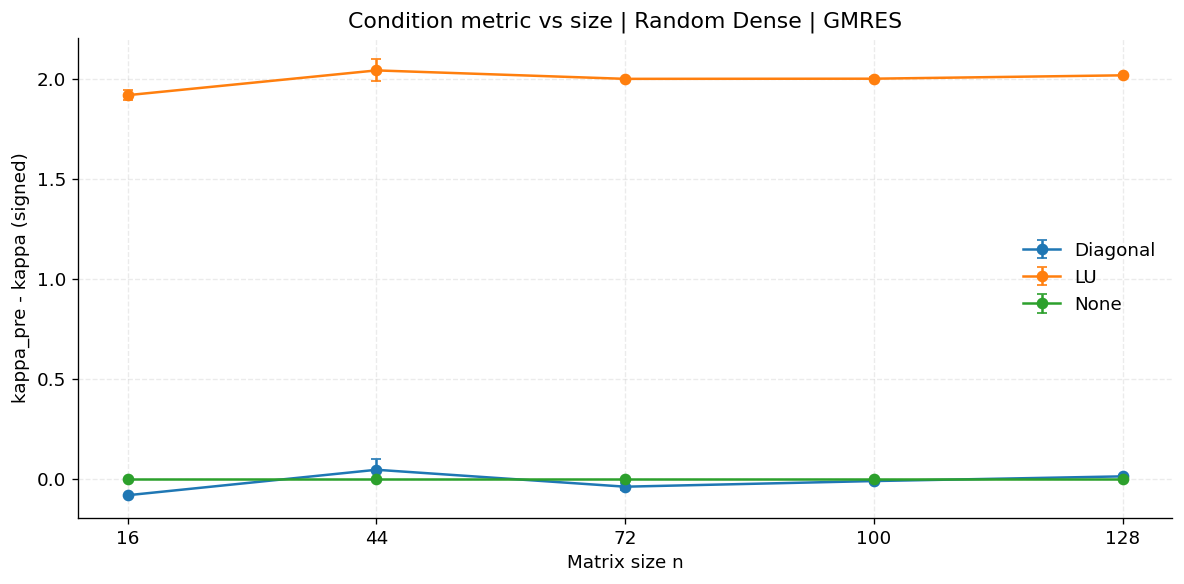

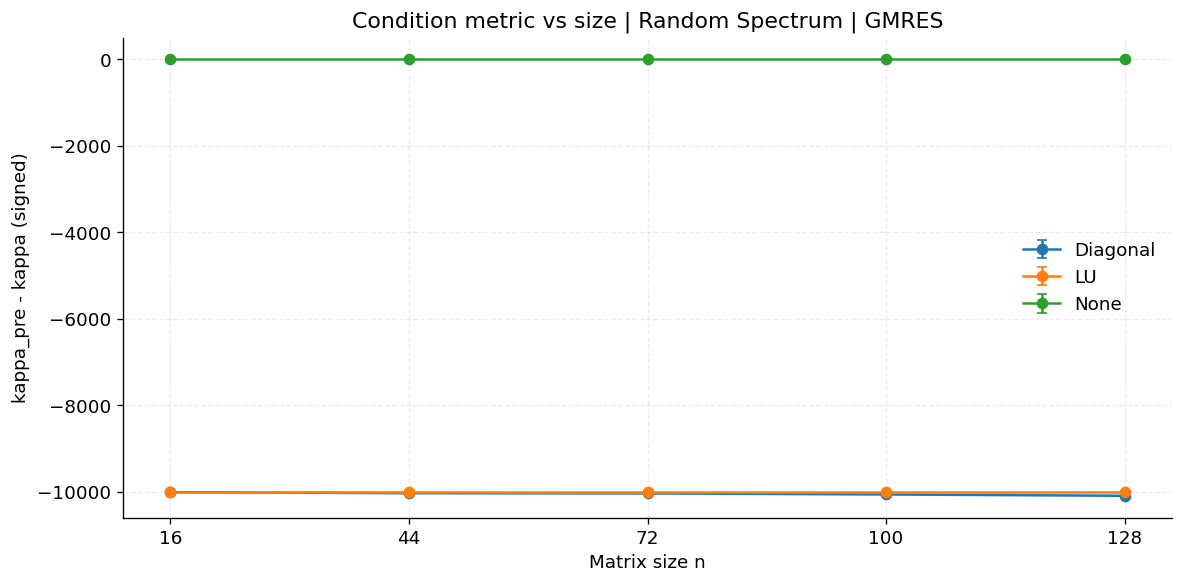

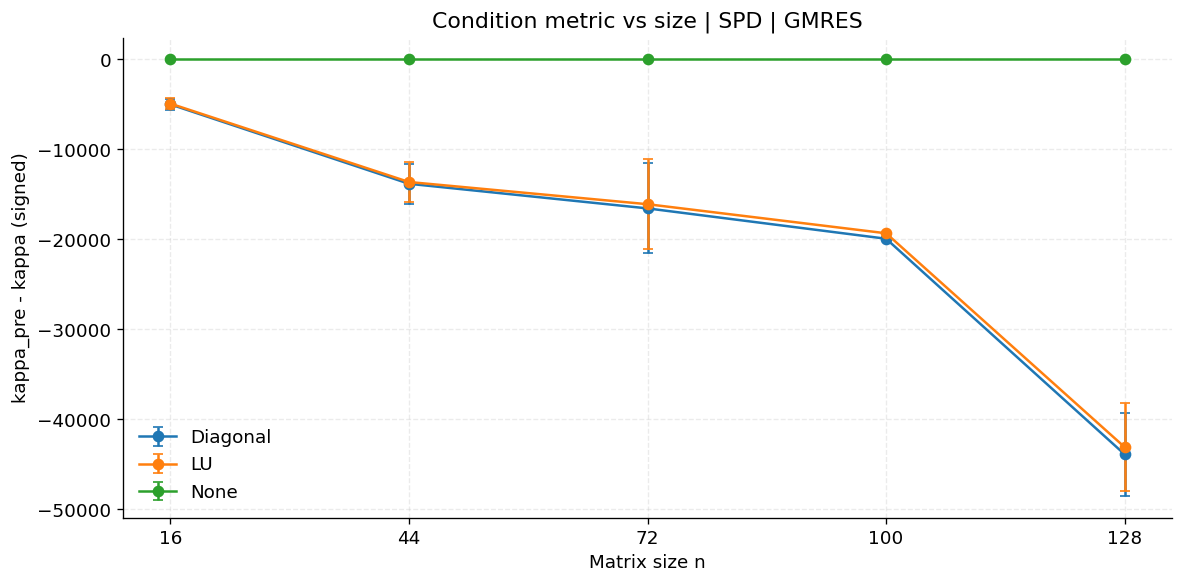

In [15]:
solver = active_solver
families = sorted({r.matrix_family for r in records})

for fam in families:
    plot_delta_kappa_vs_n(aggregated, fam, solver, metric='delta', log_y=False)


## Графики: итерации vs size

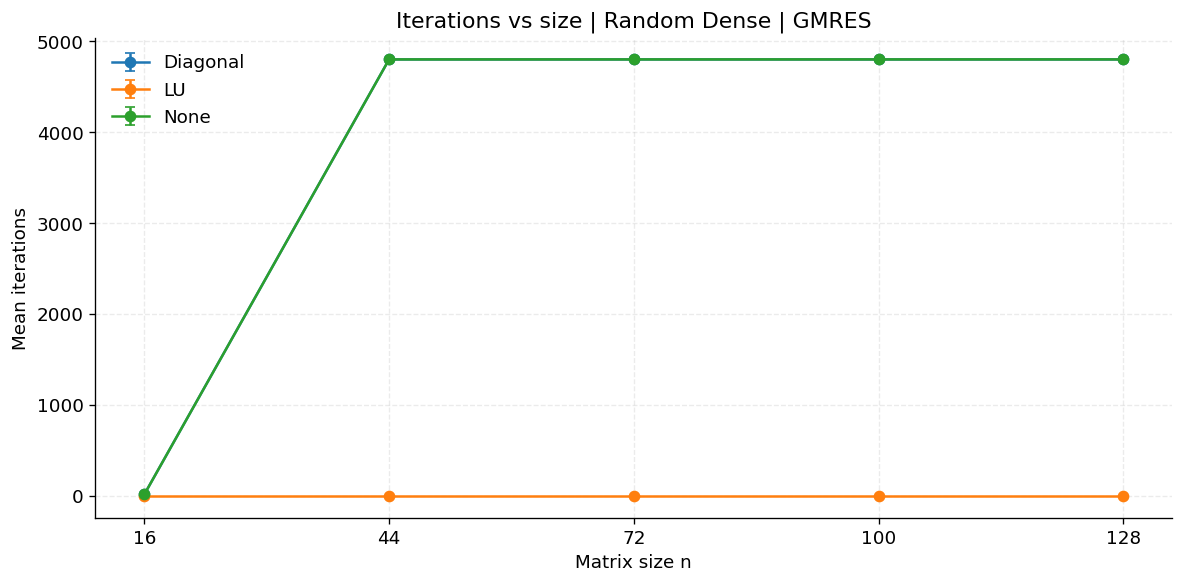

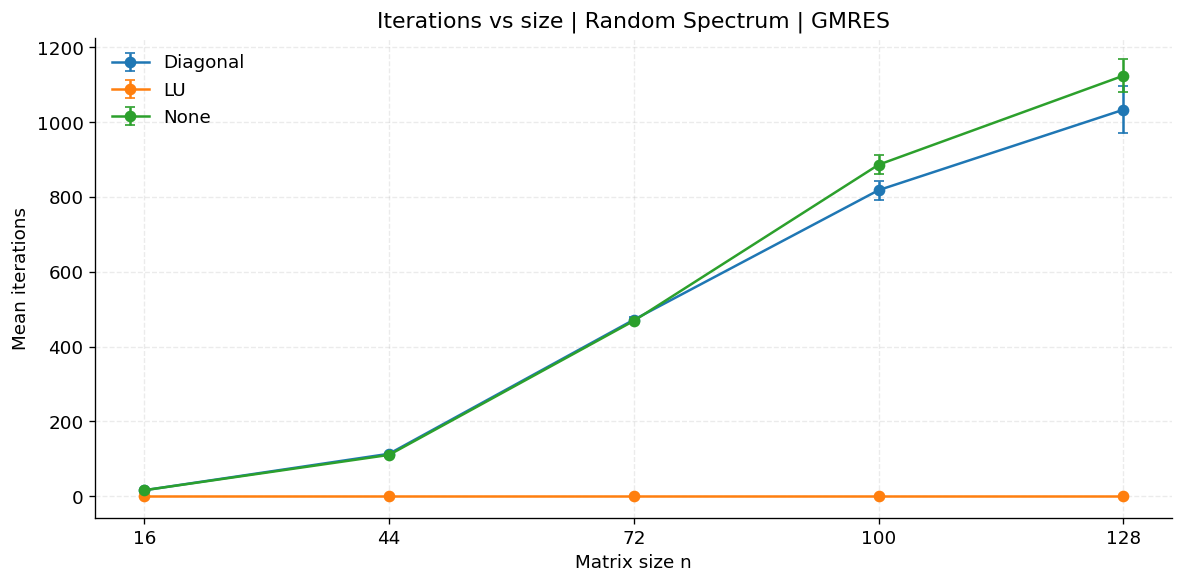

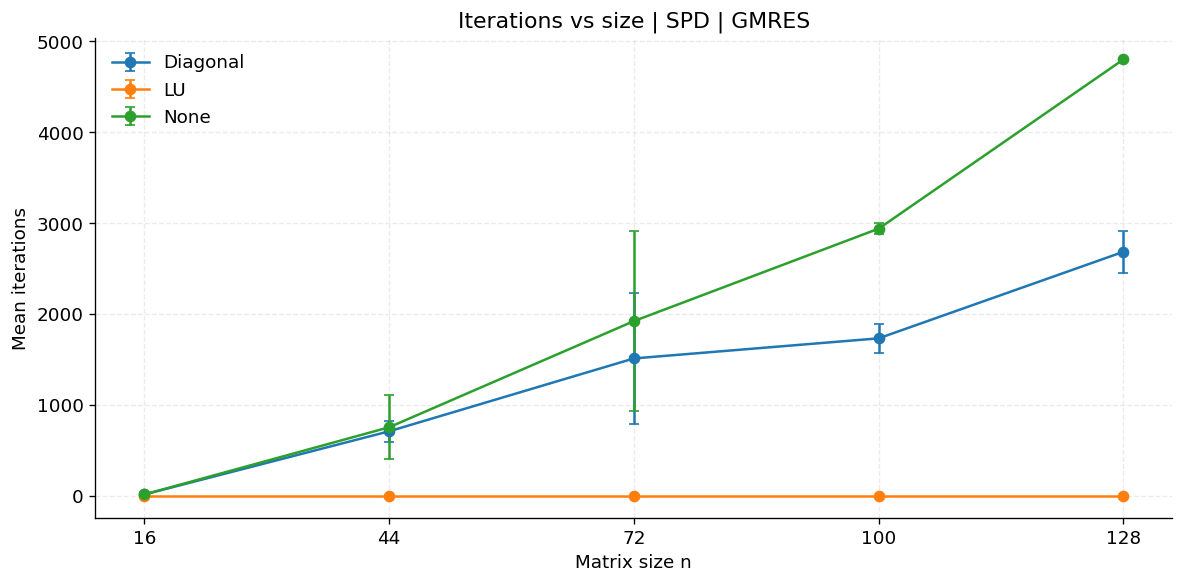

In [16]:
solver = active_solver
for fam in families:
    plot_iterations_vs_n(aggregated, fam, solver)


## Графики: delta kappa vs kappa(A)

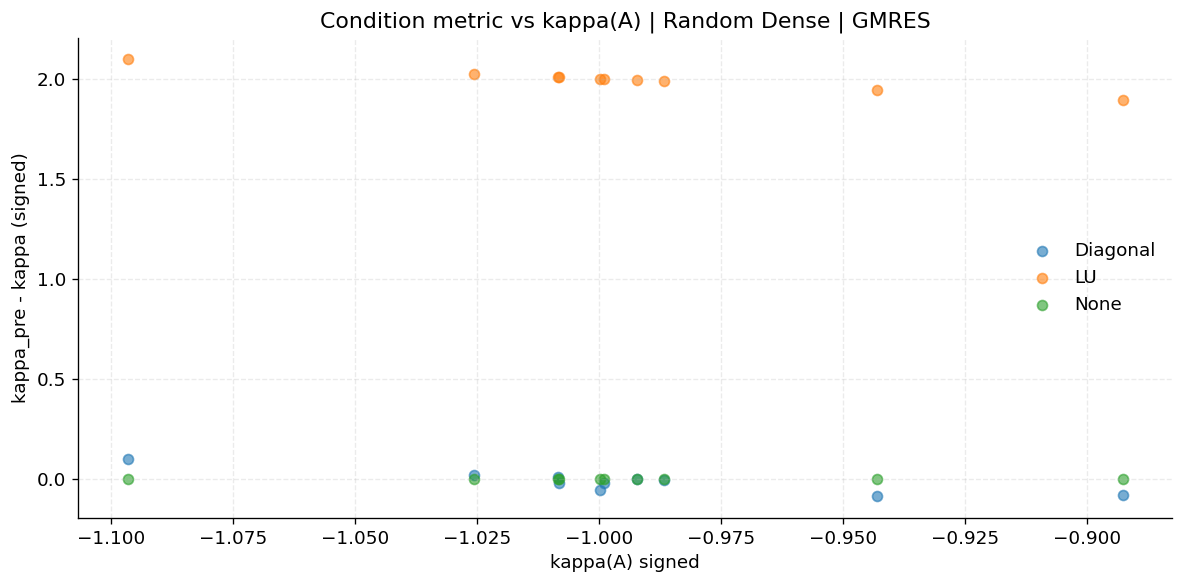

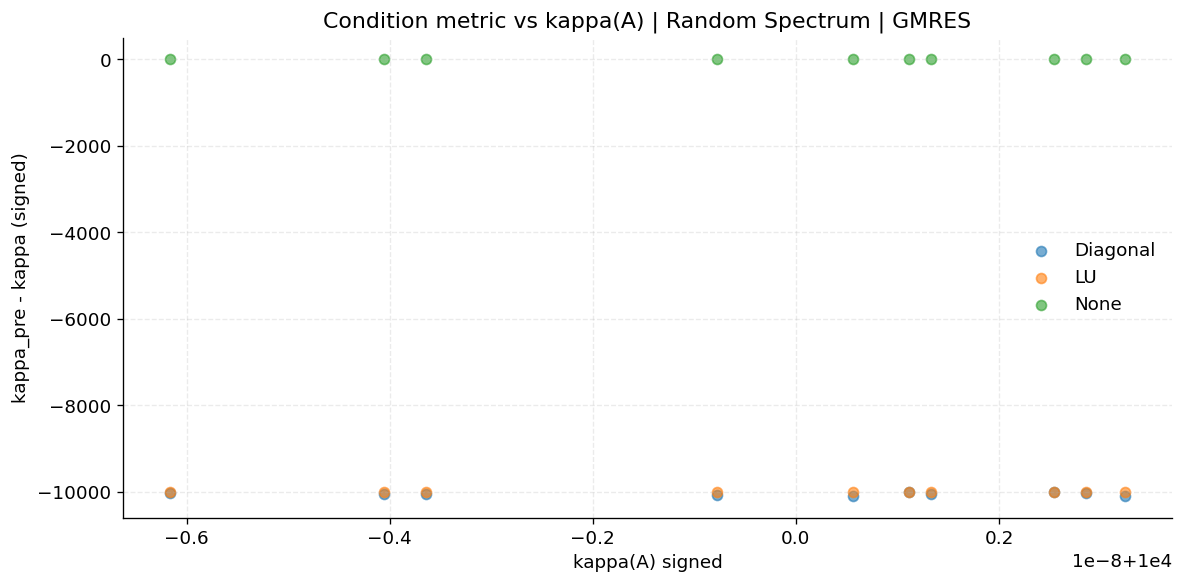

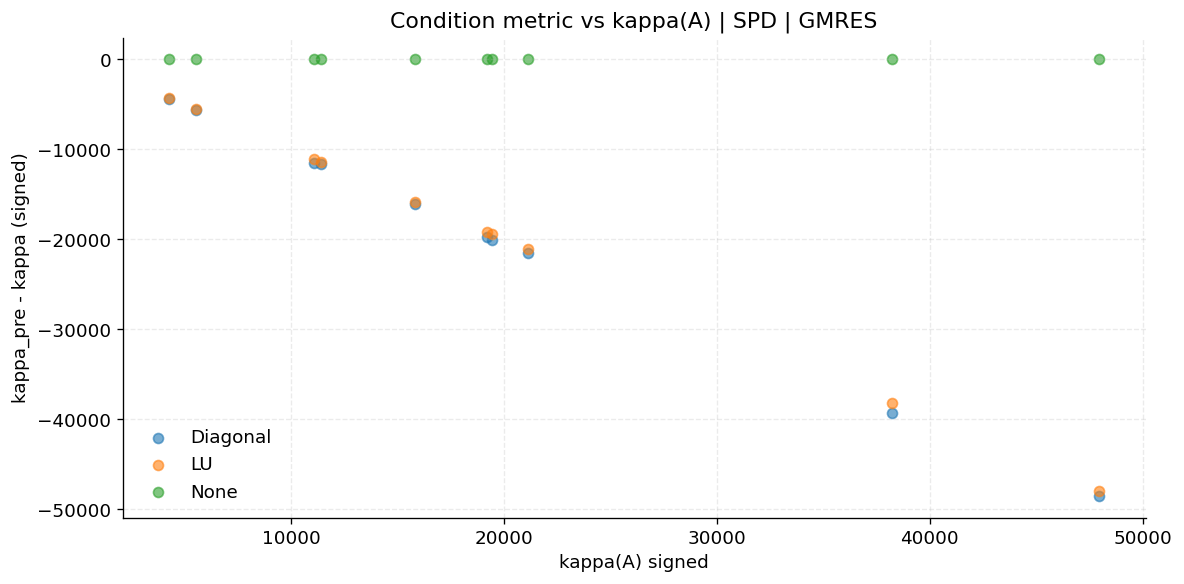

In [17]:
solver = active_solver
for fam in families:
    plot_delta_kappa_vs_kappa(
        records,
        fam,
        solver,
        metric='delta',
        x_log=False,
        y_log=False,
        max_points_per_preconditioner=200,
    )

MatrixEvaluationResult(preconditioner='Diagonal', solver='GMRES', kappa=4956.611870060622, kappa_pre=-129.50256466898315, delta_kappa=-5086.114434729605, ratio_kappa=-0.026127235309913274, converged=True, n_iter=32, residual=7.318928363962235e-14, preconditioner_time=1.06250008684583e-05, kappa_eval_time=5.379199865274131e-05, solve_time=0.002401917001407128, total_time=0.0024663340009283274)
InverseApproximationMetrics(relative_fro_error_mean=8.38456909569354e-07, relative_fro_error_std=8.694935256782035e-07, preconditioned_kappa_mean=1.000232850840054, preconditioned_kappa_std=5.6519323195568526e-05)


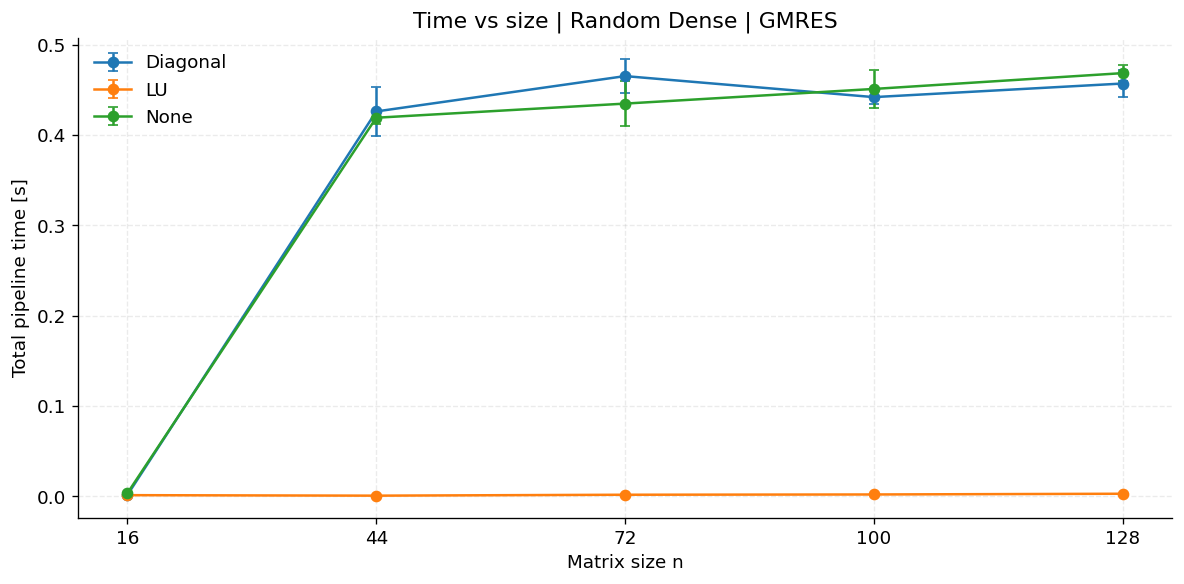

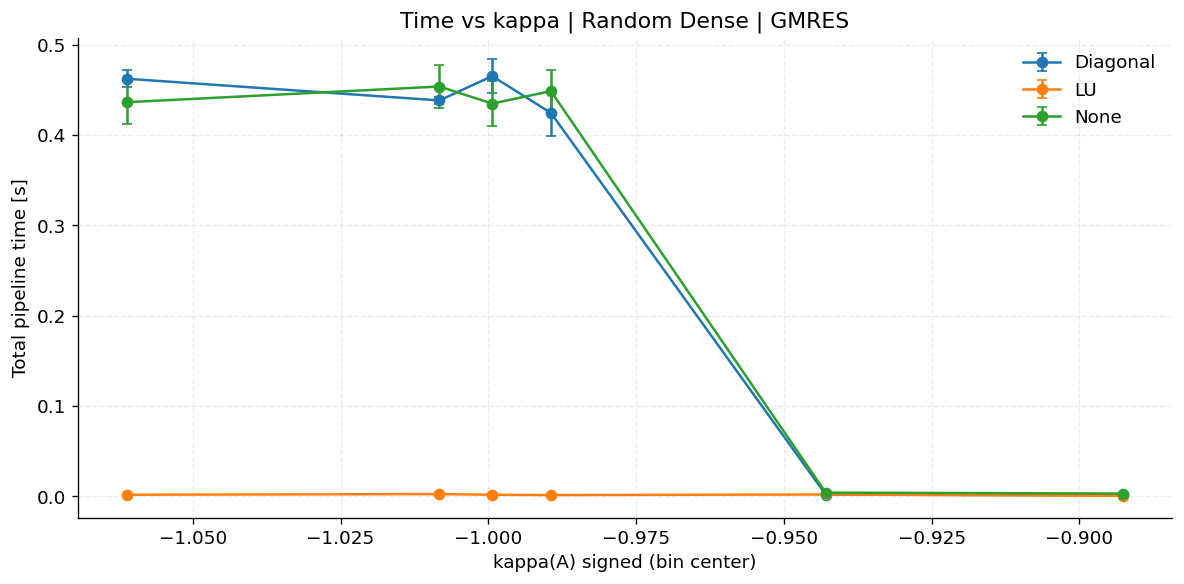

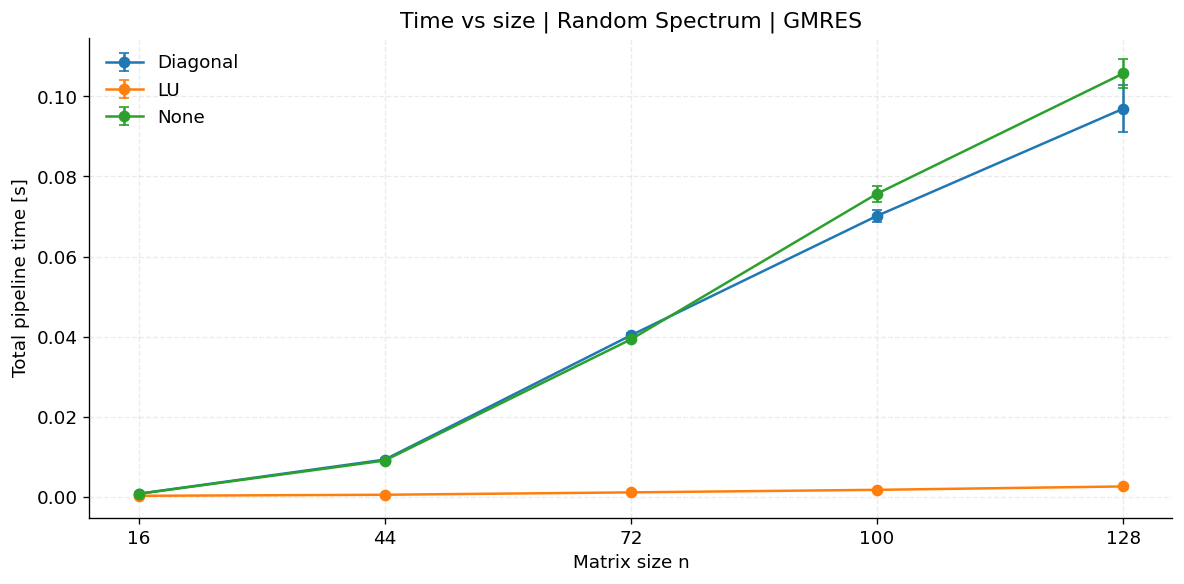

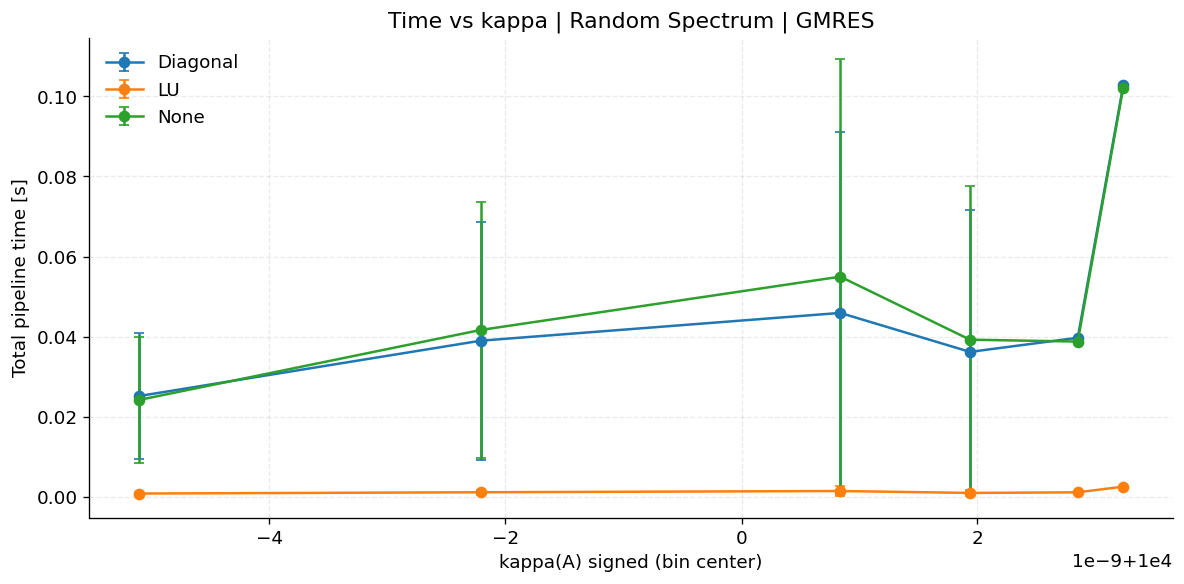

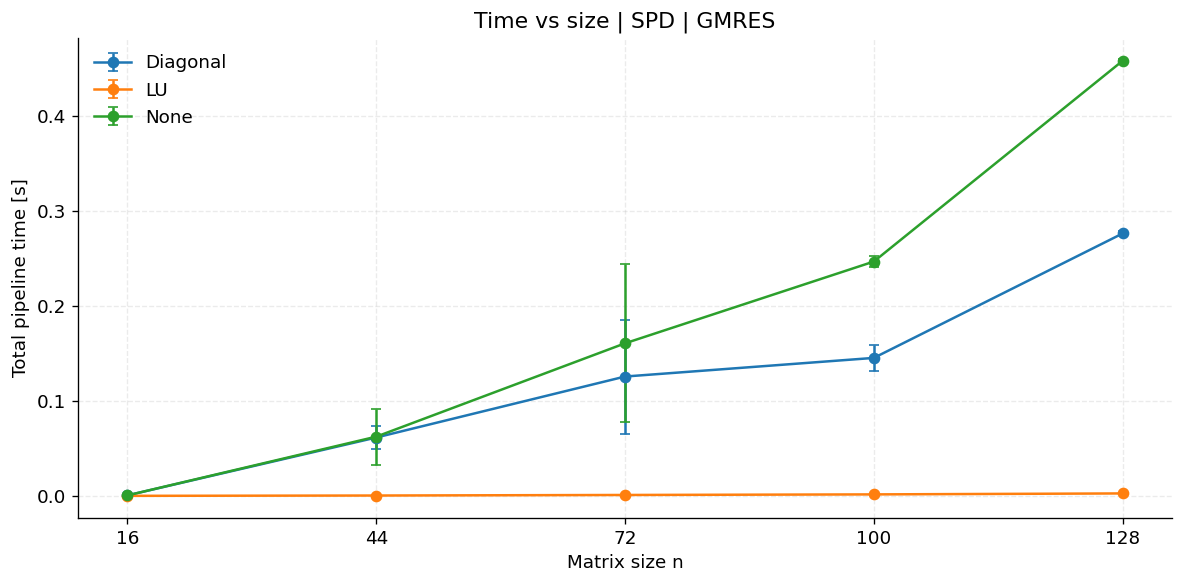

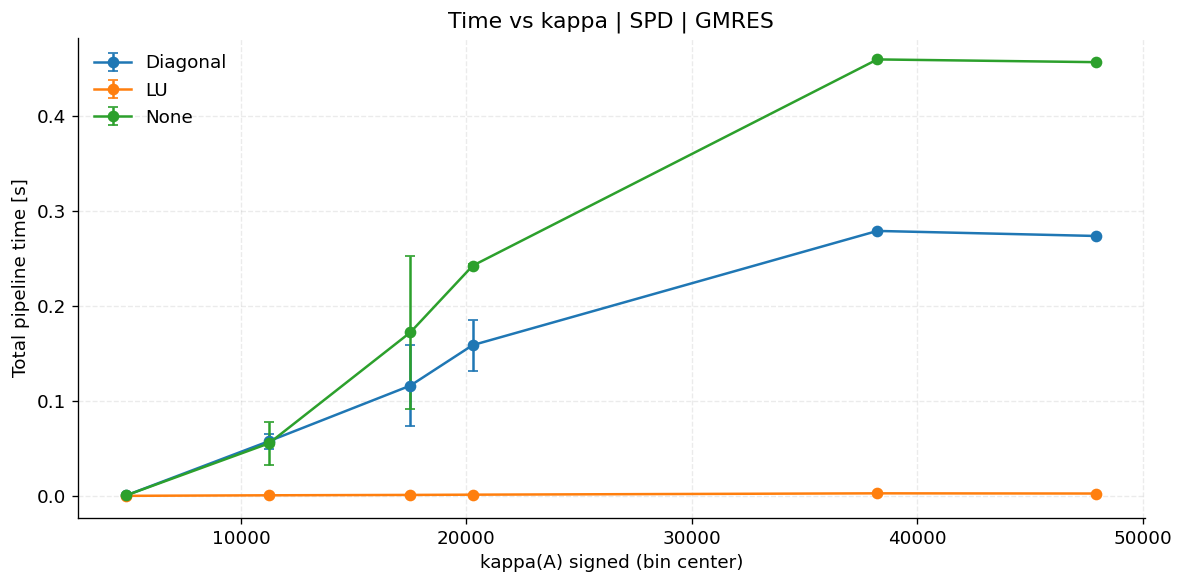

In [18]:
solver = active_solver
for fam in families:
    plot_time_vs_n(aggregated, fam, solver, metric='total')
    plot_time_vs_kappa(kappa_timing, fam, solver, metric='total', x_log=False, y_log=False)

spd = lab.make_matrix('SPD', n=32, rng_seed=1)
single = lab.evaluate_matrix(spd, preconditioner='Diagonal', solver='GMRES')
print(single)

spd_family = next(f for f in lab.matrix_families if f.name == 'SPD')
train_A, train_T = build_inverse_dataset(spd_family, n=16, n_samples=48, rng_seed=0, target='pinv')
model = RidgeInverseApproximator(matrix_size=16, ridge=1e-3).fit(train_A, train_T)
metrics = evaluate_inverse_model(model, train_A, train_T)
print(metrics)